In [1]:

import sys
#sys.path.insert(0, '../src')
sys.path.append('../')
# Import packages
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import dates as mdates
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from pmdarima import auto_arima
import pmdarima as pm
from scipy.stats import boxcox
from scipy.special import inv_boxcox

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [2]:
from notebooks.Baselines import NaiveSeasonalWithDrift, TripleExponentialSmoothing
from src.preprocessing import load_data, retrieve_airport_data
from notebooks.functions import evaluate_forecast, make_rolling_splits, make_rolling_splits_weekly


In [3]:
#Import and process weekly data for Chicago airport
data = load_data("../data/tsa-throughput-data-complete.csv")
data_ord_w = retrieve_airport_data(data, "ORD", frequency="W")


In [4]:
data_ord_w.head()

,datetime,total_passenger_throughput,week
0,2022-01-09,351922,1
1,2022-01-16,311935,2
2,2022-01-23,298777,3
3,2022-01-30,289786,4
4,2022-02-06,302673,5


In [5]:
data_ord_w.iloc[181]
data_ord_w_train= data_ord_w[data_ord_w.index <= 103]
data_ord_w_train.tail()

,datetime,total_passenger_throughput,week
99,2023-12-03,499512,48
100,2023-12-10,485039,49
101,2023-12-17,490981,50
102,2023-12-24,538606,51
103,2023-12-31,567014,52


In [6]:
#Let's visualize the weekly throughput data for Chicago O'Hare
px.line(data_ord_w, x='datetime', y='total_passenger_throughput', 
        labels={'total_passenger_throughput': 'Weekly Throughput'},
        template="simple_white", 
        title='Weekly Throughput at ORD',
        height=500, width=1000).update_layout(font=dict(size=14), title_x=0.5).show()

We want to run STL decomposition on this data. We will make time-series splits for cross-validation. We keep the data after June 29, 2025 untouched for testing.

In [7]:
data_ord_w_train= data_ord_w[data_ord_w.index <= 181]
splits = make_rolling_splits_weekly(data_ord_w_train, date_col='datetime', n_splits=5, step_weeks=13)

Split 1: train → row 116 (2024-03-31) | test rows 117–129 (2024-04-07 → 2024-06-30) (13 weeks)
Split 2: train → row 129 (2024-06-30) | test rows 130–142 (2024-07-07 → 2024-09-29) (13 weeks)
Split 3: train → row 142 (2024-09-29) | test rows 143–155 (2024-10-06 → 2024-12-29) (13 weeks)
Split 4: train → row 155 (2024-12-29) | test rows 156–168 (2025-01-05 → 2025-03-30) (13 weeks)
Split 5: train → row 168 (2025-03-30) | test rows 169–181 (2025-04-06 → 2025-06-29) (13 weeks)


Let's now run harmonic regression on the CV splits.

In [ ]:
# Make the data stationary
#data_ord_w_train['passengers_boxcox'], lam = boxcox(data_ord_w_train['total_passenger_throughput'])
#data_ord_w_train["passengers_boxcox_diff"] = data_ord_w_train["passengers_boxcox"].diff()
#data_ord_w_train.dropna(inplace=True)

In [8]:
data_ord_w_train

,datetime,total_passenger_throughput,week
0,2022-01-09,351922,1
1,2022-01-16,311935,2
2,2022-01-23,298777,3
3,2022-01-30,289786,4
4,2022-02-06,302673,5
...,...,...,...
177,2025-06-01,613076,22
178,2025-06-08,651668,23
179,2025-06-15,685144,24
180,2025-06-22,703064,25


In [9]:
from src.harmonic_model import fourier_features, time_index_feature

In [10]:
# Creat Fourier features and time index feature for daily data
ord_weekly_ff = fourier_features(data_ord_w_train['week'], m=52, k=10)
ord_weekly_ti = time_index_feature(data_ord_w_train['week'])
ord_weekly_X = np.column_stack([ord_weekly_ff, ord_weekly_ti])

In [11]:
ord_weekly_X.shape

(182, 21)

In [12]:
X_train = ord_weekly_X[splits[-1][0]]
X_test  = ord_weekly_X[splits[-1][1]]
splits[-1][1]

[169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181]

For practice, let's run the model on last split

In [13]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
X_train = ord_weekly_X[splits[-1][0]]
X_test  = ord_weekly_X[splits[-1][1]]
y_train = data_ord_w_train.iloc[splits[-1][0]].total_passenger_throughput
y_test  = data_ord_w_train.iloc[splits[-1][1]].total_passenger_throughput
model.fit(X_train, y_train)
predicted = model.predict(X_test)
metrics = {}
metrics['mse'] = mean_squared_error(y_test, predicted)
metrics['mape'] = mean_absolute_percentage_error(y_test, predicted)

1356.5695789044112
1356.5695789044112


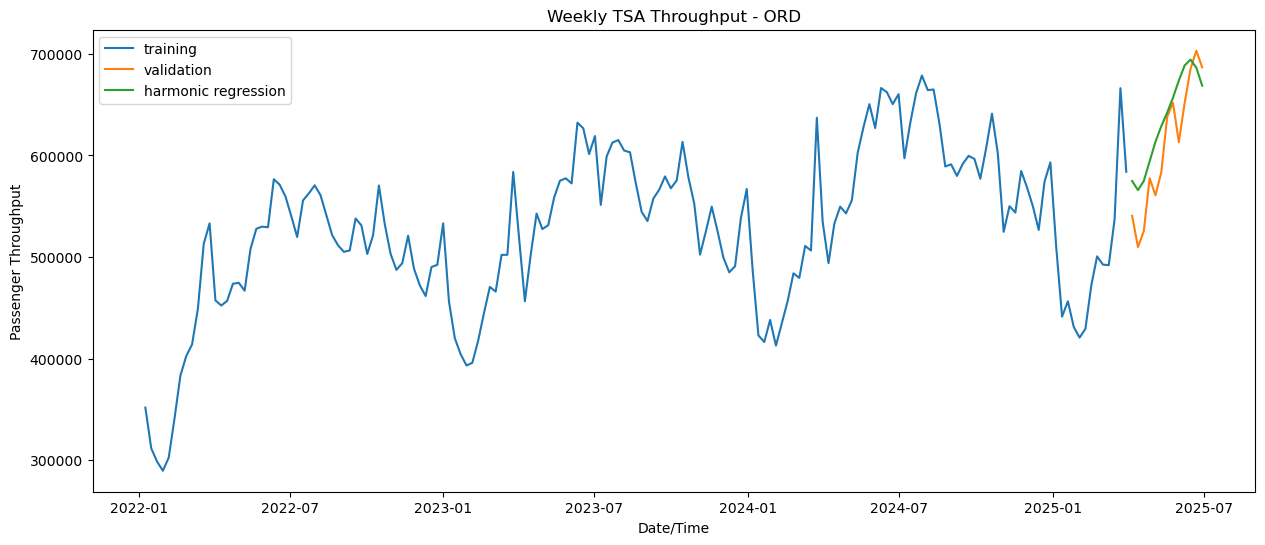

In [16]:
print(metrics['mse'] / 1e6) 
print(metrics['mape'] / 1e6)
plt.figure(figsize=(15, 6))
plt.plot(data_ord_w_train.iloc[splits[-1][0]].datetime, y_train, label='training')
plt.plot(data_ord_w_train.iloc[splits[-1][1]].datetime, y_test, label='validation')
plt.plot(data_ord_w_train.iloc[splits[-1][1]].datetime, predicted, label='harmonic regression')
plt.title('Weekly TSA Throughput - ORD')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()


Minimum metrics:
  MSE:  (24, 3,741,741,220)
  MAPE: (2, 0.09%)
  RMSE: (24, 60,970)


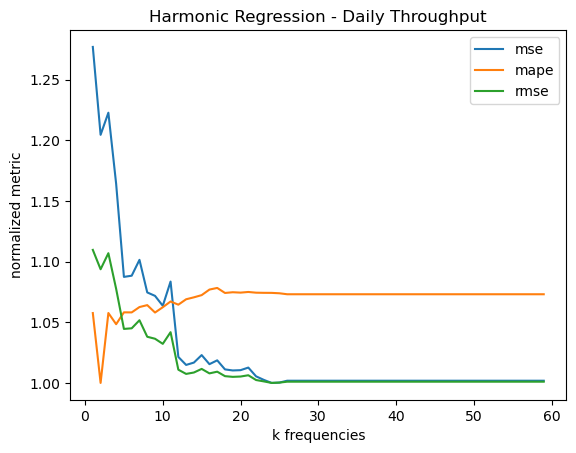

In [18]:
results = []

for k_freq in range(1, 60):
    # Determine Fourier features for the given number of frequencies
    ord_weekly_X = fourier_features(data_ord_w_train['week'], m=52, k=k_freq)
    
    k_metrics = []

    for i, (train_idx, test_idx) in enumerate(splits, start = 1):
        X_train = ord_weekly_X[train_idx]
        X_test  = ord_weekly_X[test_idx]
        y_train = data_ord_w_train.iloc[train_idx].total_passenger_throughput
        y_test  = data_ord_w_train.iloc[test_idx].total_passenger_throughput

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = {}
        metrics['split'] = i
        metrics['mse'] = mean_squared_error(y_test, y_pred)
        metrics['mape'] = mean_absolute_percentage_error(y_test, y_pred)
        metrics['rmse'] = np.sqrt(metrics['mse'])
        k_metrics.append(metrics)
    
    metrics_df = pd.DataFrame(k_metrics).set_index('split')
    mean_metrics = {}
    mean_metrics['k_freq'] = k_freq
    mean_metrics['mse']  = metrics_df['mse'].mean()
    mean_metrics['mape'] = metrics_df['mape'].mean()
    mean_metrics['rmse'] = metrics_df['rmse'].mean()
    results.append(mean_metrics)

results_df = pd.DataFrame(results).set_index('k_freq')

print(f"\nMinimum metrics:")
print(f"  MSE:  ({results_df['mse'].idxmin()}, {results_df['mse'].min():,.0f})")
print(f"  MAPE: ({results_df['mape'].idxmin()}, {results_df['mape'].min():.2f}%)")
print(f"  RMSE: ({results_df['rmse'].idxmin()}, {results_df['rmse'].min():,.0f})")

# Rescale all metrics based on their minumum value
results_df = results_df / results_df.min()
results_df.plot()
plt.title('Harmonic Regression - Daily Throughput')
plt.xlabel('k frequencies')
plt.ylabel('normalized metric')
plt.legend()
plt.show()



Minimum metrics:
  MSE:  (25, 843,220,603)
  MAPE: (25, 0.04%)
  RMSE: (24, 27,404)


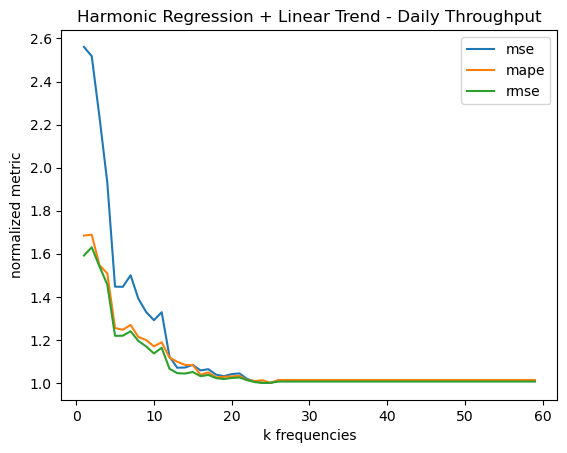

In [20]:
# We repeat the same process with the linear trend as well
results = []

for k_freq in range(1, 60):
    # Determine Fourier features for the given number of frequencies
    ord_weekly_ff = fourier_features(data_ord_w_train['week'], m=52, k=k_freq)
    ord_weekly_ti = time_index_feature(data_ord_w_train['week'])
    ord_weekly_X = np.column_stack([ord_weekly_ff, ord_weekly_ti])
    
    k_metrics = []

    for i, (train_idx, test_idx) in enumerate(splits, start = 1):
        X_train = ord_weekly_X[train_idx]
        X_test  = ord_weekly_X[test_idx]
        y_train = data_ord_w_train.iloc[train_idx].total_passenger_throughput
        y_test  = data_ord_w_train.iloc[test_idx].total_passenger_throughput

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = {}
        metrics['split'] = i
        metrics['mse'] = mean_squared_error(y_test, y_pred)
        metrics['mape'] = mean_absolute_percentage_error(y_test, y_pred)
        metrics['rmse'] = np.sqrt(metrics['mse'])
        k_metrics.append(metrics)
    
    metrics_df = pd.DataFrame(k_metrics).set_index('split')
    mean_metrics = {}
    mean_metrics['k_freq'] = k_freq
    mean_metrics['mse']  = metrics_df['mse'].mean()
    mean_metrics['mape'] = metrics_df['mape'].mean()
    mean_metrics['rmse'] = metrics_df['rmse'].mean()
    results.append(mean_metrics)

results_df = pd.DataFrame(results).set_index('k_freq')

print(f"\nMinimum metrics:")
print(f"  MSE:  ({results_df['mse'].idxmin()}, {results_df['mse'].min():,.0f})")
print(f"  MAPE: ({results_df['mape'].idxmin()}, {results_df['mape'].min():.2f}%)")
print(f"  RMSE: ({results_df['rmse'].idxmin()}, {results_df['rmse'].min():,.0f})")

# Rescale all metrics based on their minumum value
results_df = results_df / results_df.min()
results_df.plot()
plt.title('Harmonic Regression + Linear Trend - Daily Throughput')
plt.xlabel('k frequencies')
plt.ylabel('normalized metric')
plt.legend()
plt.show()

In [21]:
import pmdarima as pm

In [23]:
# Like before, we first test it out on just one split
ord_weekly_X = fourier_features(data_ord_w_train['week'], m=52, k=2)

X_train = ord_weekly_X[splits[0][0]]
X_test  = ord_weekly_X[splits[0][1]]
y_train = data_ord_w_train.iloc[splits[0][0]].total_passenger_throughput
y_test  = data_ord_w_train.iloc[splits[0][1]].total_passenger_throughput

arima_model = pm.auto_arima(
    y_train,
    X=X_train,
    seasonal=True, m=4,
    d=1, D=0,
    # start_p=0, max_p=1,
    # start_q=0, max_q=1,
    # start_P=0, max_P=1,
    # start_Q=0, max_Q=1,
    stepwise=True,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[4] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=2757.676, Time=0.00 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=2758.744, Time=0.02 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=2758.148, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=3192.188, Time=0.00 sec
 ARIMA(0,1,0)(1,0,0)[4] intercept   : AIC=2759.205, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[4] intercept   : AIC=2759.206, Time=0.01 sec
 ARIMA(0,1,0)(1,0,1)[4] intercept   : AIC=2761.204, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=2757.184, Time=0.01 sec
 ARIMA(1,1,0)(0,0,1)[4] intercept   : AIC=2758.740, Time=0.02 sec
 ARIMA(1,1,0)(1,0,1)[4] intercept   : AIC=2760.740, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[4] intercept   : AIC=2756.363, Time=0.02 sec
 ARIMA(2,1,0)(1,0,0)[4] intercept   : AIC=2758.145, Time=0.03 sec
 ARIMA(2,1,0)(0,0,1)[4] intercept   : AIC=2758.145, Time=0.02 sec
 ARIMA(2,1,0)(1,0,1)[4] intercept   : 

In [25]:
# The best fitting ARIMA was (4,1,2)(1,0,1)[7] without intercept
# ARIMA(3,1,0)(0,0,0)[4]
#
# Now we cross-validate along every fold and compare with the baseline models

# Determine Fourier features for the optimized number of frequencies
ord_weekly_X = fourier_features(data_ord_w_train['week'], m=52, k=2)

results = []

for i, (train_idx, test_idx) in enumerate(splits, start = 1):
    X_train = ord_weekly_X[train_idx]
    X_test  = ord_weekly_X[test_idx]
    y_train = data_ord_w_train.iloc[train_idx].total_passenger_throughput
    y_test  = data_ord_w_train.iloc[test_idx].total_passenger_throughput

    # Establish baseline models and Harmonic model to compare
    nswd_year_model = NaiveSeasonalWithDrift(season_length=52)
    nswd_month_model = NaiveSeasonalWithDrift(season_length=4)
    exps_year_model = TripleExponentialSmoothing(season_length=52)
    exps_month_model = TripleExponentialSmoothing(season_length=4)
    harmonic_model = pm.ARIMA(order=(3,1,0), seasonal_order=(0,0,0,4), with_intercept=False)

    # Fit models
    nswd_year_model.fit(y_train)
    nswd_month_model.fit(y_train)
    exps_year_model.fit(y_train)
    exps_month_model.fit(y_train)
    harmonic_model.fit(y_train, X_train)

    # Evaluate models
    nwsd_year_pred = nswd_year_model.forecast(h=len(y_test))
    nwsd_month_pred = nswd_month_model.forecast(h=len(y_test))
    exps_year_pred = exps_year_model.forecast(h=len(y_test))
    exps_month_pred = exps_month_model.forecast(h=len(y_test))
    harmonic_pred = harmonic_model.predict(n_periods=len(y_test), X=X_test)

    metrics = {}
    metrics['model'] = 'nswd_year'
    metrics['split'] = i
    metrics['mse'] = mean_squared_error(y_test, nwsd_year_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, nwsd_year_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    results.append(metrics)

    metrics = {}
    metrics['model'] = 'nswd_month'
    metrics['split'] = i
    metrics['mse'] = mean_squared_error(y_test, nwsd_month_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, nwsd_month_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    results.append(metrics)

    metrics = {}
    metrics['model'] = 'exps_year'
    metrics['split'] = i
    metrics['mse'] = mean_squared_error(y_test, exps_year_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, exps_year_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    results.append(metrics)

    metrics = {}
    metrics['model'] = 'exps_month'
    metrics['split'] = i
    metrics['mse'] = mean_squared_error(y_test, exps_month_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, exps_month_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    results.append(metrics)

    metrics = {}
    metrics['model'] = 'harmonic'
    metrics['split'] = i
    metrics['mse'] = mean_squared_error(y_test, harmonic_pred)
    metrics['mape'] = mean_absolute_percentage_error(y_test, harmonic_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])
    results.append(metrics)

    print(f"Finished split {i}")

cv_means = pd.DataFrame(results).groupby(by=["model"])[["mse", "mape", "rmse"]].mean()

print(f"\nCV Results:")
# print(f"  MSE: {cv_means['mse']:,.0f}")
# print(f"  MAPE: {cv_means['mape']:.2f}%")
# print(f"  RMSE: {cv_means['rmse']:,.0f}")
print(cv_means)

Finished split 1
Finished split 2
Finished split 3
Finished split 4
Finished split 5

CV Results:
                     mse      mape           rmse
model                                            
exps_month  7.025675e+09  0.127456   80652.199747
exps_year   7.639180e+08  0.041143   27170.722062
harmonic    3.922408e+09  0.095480   57249.992281
nswd_month  1.323118e+10  0.171144  107495.284506
nswd_year   8.978650e+08  0.041210   27780.543159
